In [ ]:
!pip install kumoai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.4/404.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 3.2 MB/s eta 0:00:00


In [ ]:
!gcloud auth application-default login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=bHBnT5TmuYUK8ghTgjGbadq9IeE8xz&prompt=consent&token_usage=remote&access_type=offline&code_challenge=OA_VsESA_JEywzPXvHiFIaZavfrPfrYbQ13q4ASUMCM&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AdkVLPyDwnpEsBc7JdjZiheLh-WXwNBz24tE_t9KrwakwB-aJCJk1S_dnCkiWS4KPF8lvw

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [ ]:
import os
import kumoai.experimental.rfm as rfm, os
import pandas as pd

from google.cloud import bigquery

In [ ]:
KUMO_API_KEY = os.environ.get("KUMO_API_KEY")
rfm.init(api_key=KUMO_API_KEY)

INFO:kumoai:Initialized Kumo SDK v2.22.0 against deployment 'https://kumorfm.ai/api'


In [ ]:
import pandas as pd
from google.cloud import bigquery

client = bigquery.Client(project="diesel-charge-465712-f8")

print("Fetching complete datasets from BigQuery...")

# Core Queries
icustays_df = client.query("SELECT subject_id, hadm_id, icustay_id as stay_id, intime, outtime, los FROM `physionet-data.mimiciii_clinical.icustays`").to_dataframe()
patients_df = client.query("SELECT subject_id, gender, dob FROM `physionet-data.mimiciii_clinical.patients`").to_dataframe()
admissions_df = client.query("""SELECT hadm_id, subject_id, admittime, dischtime, deathtime, admission_type, admission_location, insurance, religion, marital_status, ethnicity, discharge_location FROM `physionet-data.mimiciii_clinical.admissions`""").to_dataframe()
diagnoses_df = client.query("SELECT hadm_id, subject_id, seq_num, icd9_code as icd_code FROM `physionet-data.mimiciii_clinical.diagnoses_icd`").to_dataframe()
procedures_df = client.query("SELECT hadm_id, subject_id, seq_num, icd9_code as procedure_code FROM `physionet-data.mimiciii_clinical.procedures_icd`").to_dataframe()
transfers_df = client.query("""SELECT row_id as transfer_id, hadm_id, subject_id, icustay_id as stay_id, eventtype, curr_careunit, intime as transfer_intime, outtime as transfer_outtime FROM `physionet-data.mimiciii_clinical.transfers`""").to_dataframe()
services_df = client.query("""SELECT row_id as service_id, hadm_id, subject_id, transfertime, prev_service, curr_service FROM `physionet-data.mimiciii_clinical.services`""").to_dataframe()

# --- POST-PROCESSING & STABILIZATION ---

# 1. Enforce strict datetime types across EVERY single time column immediately
admissions_df['admittime'] = pd.to_datetime(admissions_df['admittime'])
admissions_df['deathtime'] = pd.to_datetime(admissions_df['deathtime'])
admissions_df['dischtime'] = pd.to_datetime(admissions_df['dischtime'])
icustays_df['intime'] = pd.to_datetime(icustays_df['intime'])
icustays_df['outtime'] = pd.to_datetime(icustays_df['outtime'])
transfers_df['transfer_intime'] = pd.to_datetime(transfers_df['transfer_intime'])
transfers_df['transfer_outtime'] = pd.to_datetime(transfers_df['transfer_outtime'])
services_df['transfertime'] = pd.to_datetime(services_df['transfertime'])
patients_df['dob'] = pd.to_datetime(patients_df['dob'])

# 2. Map surrogate tracking keys for graph structure stability
procedures_df = procedures_df.reset_index().rename(columns={'index': 'procedure_id'})
diagnoses_df = diagnoses_df.reset_index().rename(columns={'index': 'diagnoses_id'})

# 3. Safely map admissions timeline coordinates to clinical data tables
diagnoses_df = diagnoses_df.merge(admissions_df[['hadm_id', 'admittime']], on='hadm_id', how='left')
procedures_df = procedures_df.merge(admissions_df[['hadm_id', 'admittime']], on='hadm_id', how='left')

# Ensure these merged dates are strictly treated as datetimes
diagnoses_df['admittime'] = pd.to_datetime(diagnoses_df['admittime'])
procedures_df['admittime'] = pd.to_datetime(procedures_df['admittime'])

# 4. Apply distinct microsecond/second deltas to operational tables to prevent simultaneous t0 blocks
transfers_df['transfer_intime'] = transfers_df['transfer_intime'] + pd.to_timedelta(1, unit='s')
services_df['transfertime'] = services_df['transfertime'] + pd.to_timedelta(1, unit='s')

# 5. Target Construction: 48-Hour Mortality Calculation
icustays_df = icustays_df.merge(admissions_df[['hadm_id', 'deathtime']], on='hadm_id', how='left')
icustays_df['died_within_48h'] = (
    icustays_df['deathtime'].notna() &
    ((icustays_df['deathtime'] - icustays_df['intime']).dt.total_seconds() / 3600.0 <= 48.0)
).astype(int)

# --- CRITICAL SAFETY SANITY CHECK ---
print("\n--- RUNNING TIMELINE VARIANCE CHECK ---")
print("Are admission times uniform or diverse?")
print(admissions_df['admittime'].value_counts().head(3))
print("\nAre ICU stay times uniform or diverse?")
print(icustays_df['intime'].value_counts().head(3))

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Fetching complete datasets from BigQuery...

--- RUNNING TIMELINE VARIANCE CHECK ---
Are admission times uniform or diverse?
admittime
2191-08-23 07:15:00    4
2105-02-09 07:15:00    4
2121-04-30 08:00:00    3
Name: count, dtype: int64

Are ICU stay times uniform or diverse?
intime
2112-07-18 10:56:00    2
2165-04-12 05:32:40    1
2117-12-06 10:57:38    1
Name: count, dtype: int64


In [ ]:
len(patients_df) + len(admissions_df) + len(icustays_df) + len(diagnoses_df) + len(procedures_df) + len(transfers_df) + len(services_df)

1393410

In [ ]:
tables_dict = {
    'patients': patients_df,
    'admissions': admissions_df,
    'icustays': icustays_df,
    'diagnoses_icd': diagnoses_df,
    'procedures_icd': procedures_df,
    'transfers': transfers_df,
    'services': services_df
}

In [ ]:
def preprocess_tables_dict(tables_dict):
    for table_name, df in tables_dict.items():
      dbdate_columns = df.dtypes[df.dtypes == 'dbdate'].index.tolist()
      for col in dbdate_columns:
        df[col] = pd.to_datetime(df[col])

    return tables_dict

In [ ]:
def transform_to_rfm_table(tables_dict):
  result = {}
  for table_name, df in tables_dict.items():
    rfm_table = rfm.LocalTable(
      df = df,
      name = table_name
    ).infer_metadata()
    result[table_name] = rfm_table
  return result

In [ ]:
tables_dict = preprocess_tables_dict(tables_dict)

Inferred time column `dob` for table `patients`

Inferred time column `admittime` for table `admissions`

Inferred time column `intime` for table `icustays`

Inferred time column `admittime` for table `diagnoses_icd`

Inferred time column `admittime` for table `procedures_icd`

Inferred primary key `transfer_id` and time column `transfer_intime` for table `transfers`

Inferred primary key `service_id` and time column `transfertime` for table `services`

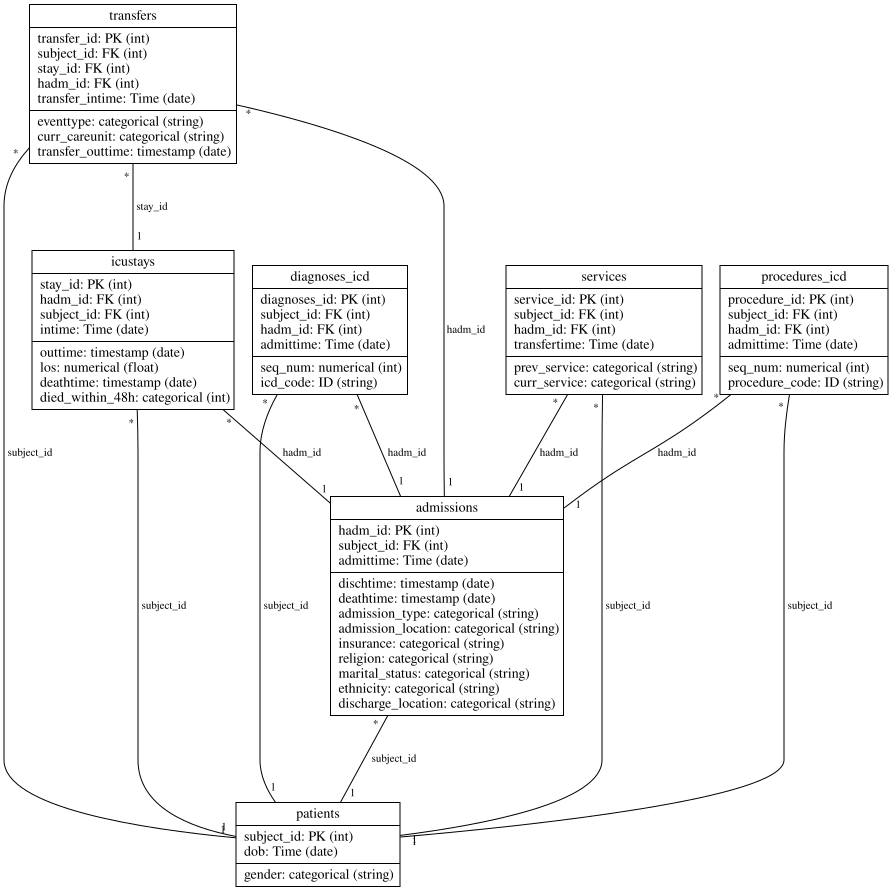

In [ ]:
tables = transform_to_rfm_table(tables_dict)

tables['patients'].primary_key = "subject_id"
tables['admissions'].primary_key = "hadm_id"
tables['icustays'].primary_key = "stay_id"
tables['diagnoses_icd'].primary_key = "diagnoses_id"
tables['procedures_icd'].primary_key = "procedure_id"
tables['transfers'].primary_key = "transfer_id"
tables['services'].primary_key = "service_id"

graph = rfm.LocalGraph(tables=tables.values())

graph.link(src_table="admissions", fkey="subject_id", dst_table="patients")

graph.link(src_table="icustays", fkey="hadm_id", dst_table="admissions")
graph.link(src_table="icustays", fkey="subject_id", dst_table="patients")

graph.link(src_table="diagnoses_icd", fkey="subject_id", dst_table="patients")
graph.link(src_table="diagnoses_icd", fkey="hadm_id", dst_table="admissions")

graph.link(src_table="procedures_icd", fkey="subject_id", dst_table="patients")
graph.link(src_table="procedures_icd", fkey="hadm_id", dst_table="admissions")

graph.link(src_table="services", fkey="subject_id", dst_table="patients")
graph.link(src_table="services", fkey="hadm_id", dst_table="admissions")

graph.link(src_table="transfers", fkey="subject_id", dst_table="patients")
graph.link(src_table="transfers", fkey="stay_id", dst_table="icustays")
graph.link(src_table="transfers", fkey="hadm_id", dst_table="admissions")

graph.visualize()

In [ ]:
model = rfm.KumoRFM(graph=graph)

Output()

In [ ]:
query = """
PREDICT icustays.died_within_48h
FOR EACH icustays.stay_id
"""

patient_ids = tables_dict['icustays']['stay_id'].dropna().astype(int).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=patient_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,CLASS,SCORE,PREDICTED
0,203333,2210-08-24 19:43:12,0,0.999964,True
1,203333,2210-08-24 19:43:12,1,0.000036,False
2,299036,2210-08-24 19:43:12,0,0.999855,True
3,299036,2210-08-24 19:43:12,1,0.000145,False
4,209490,2210-08-24 19:43:12,0,0.999085,True


In [ ]:
metrics = model.evaluate(
    query,
    metrics=['acc', 'precision', 'recall', 'f1', 'mrr']
)

metrics

Output()

,metric,value
0,acc,0.977500
1,f1,0.735629
2,mrr,0.988750
3,precision,0.926872
4,recall,0.665892


In [ ]:
len(icustays_df)

61532

In [ ]:
query = """
PREDICT icustays.los
FOR EACH icustays.stay_id
"""

hadm_ids = tables_dict['icustays']['stay_id'].dropna().astype(int).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=hadm_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,203333,2210-08-24 19:43:12,2.545459
1,299036,2210-08-24 19:43:12,2.108057
2,209490,2210-08-24 19:43:12,5.888367
3,212996,2210-08-24 19:43:12,1.909593
4,298791,2210-08-24 19:43:12,3.086443


In [ ]:
metrics = model.evaluate(
    query,
    metrics=['mae', 'mape', 'mse', 'rmse', 'smape', 'r2']
)

metrics

Output()

,metric,value
0,mae,3.446874
1,mape,2.244632
2,mse,82.207909
3,r2,0.368378
4,rmse,9.066857
5,smape,0.614271


In [ ]:
query = """
PREDICT COUNT(icustays.*, 0, 365, days)
FORECAST 10 TIMEFRAMES
FOR EACH patients.subject_id
"""

hadm_ids = patients_df['subject_id'].dropna().astype(int).tolist()
with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=[13033,], anchor_time=pd.Timestamp('2187-12-17 20:54:00'))

        display(df)

    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,TIME,TARGET_PRED
0,13033,2187-12-17 20:54:00,2187-12-17 20:54:00,9.000000
1,13033,2187-12-17 20:54:00,2188-12-16 20:54:00,10.883985
2,13033,2187-12-17 20:54:00,2189-12-16 20:54:00,11.375154
3,13033,2187-12-17 20:54:00,2190-12-16 20:54:00,11.378286
4,13033,2187-12-17 20:54:00,2191-12-16 20:54:00,9.000000
5,13033,2187-12-17 20:54:00,2192-12-15 20:54:00,9.000000
6,13033,2187-12-17 20:54:00,2193-12-15 20:54:00,10.903913
7,13033,2187-12-17 20:54:00,2194-12-15 20:54:00,10.770702
8,13033,2187-12-17 20:54:00,2195-12-15 20:54:00,10.764311
9,13033,2187-12-17 20:54:00,2196-12-14 20:54:00,10.846310


In [ ]:
query = """
PREDICT COUNT(procedures_icd.*, 0, 365, days)
FORECAST 10 TIMEFRAMES
FOR patients.subject_id = 13033
"""

hadm_ids = patients_df['subject_id'].dropna().astype(int).tolist()
with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=[13033,], anchor_time=pd.Timestamp('2187-12-17 20:54:00'))

        display(df)

    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,TIME,TARGET_PRED
0,13033,2187-12-17 20:54:00,2187-12-17 20:54:00,12.475324
1,13033,2187-12-17 20:54:00,2188-12-16 20:54:00,21.288597
2,13033,2187-12-17 20:54:00,2189-12-16 20:54:00,21.673878
3,13033,2187-12-17 20:54:00,2190-12-16 20:54:00,21.755569
4,13033,2187-12-17 20:54:00,2191-12-16 20:54:00,12.096891
5,13033,2187-12-17 20:54:00,2192-12-15 20:54:00,16.353273
6,13033,2187-12-17 20:54:00,2193-12-15 20:54:00,21.580994
7,13033,2187-12-17 20:54:00,2194-12-15 20:54:00,21.531460
8,13033,2187-12-17 20:54:00,2195-12-15 20:54:00,21.517864
9,13033,2187-12-17 20:54:00,2196-12-14 20:54:00,21.511158


In [ ]:
patients_df

,subject_id,gender,dob
0,56,F,1804-01-02
1,18848,F,2042-08-21
2,61056,F,2067-04-11
3,26889,F,2115-11-04
4,18333,F,2094-01-21
...,...,...,...
46515,44065,M,2116-03-30
46516,44069,M,2064-04-08
46517,44071,M,2097-11-14
46518,44089,M,2026-05-25


In [ ]:
import random
import pandas as pd

# 1. Define your temporal parameters
anchor_time = pd.Timestamp('2110-01-01')
lookahead_end = anchor_time + pd.Timedelta(days=365)

# 2. Identify patients who actually had an admission within that specific 1-year window
admitted_subject_ids = admissions_df[
    (admissions_df['admittime'] >= anchor_time) &
    (admissions_df['admittime'] <= lookahead_end)
]['subject_id'].dropna().unique()

# 3. Identify all unique patients in your dataset
all_subject_ids = patients_df['subject_id'].dropna().unique()

# 4. Divide your patients into two mutually exclusive groups
group_with_admission = list(set(admitted_subject_ids))
group_without_admission = list(set(all_subject_ids) - set(admitted_subject_ids))

# 5. Determine the maximum safe sample size to guarantee a perfect 50/50 split
sample_size = min(len(group_with_admission), len(group_without_admission))

# 6. Sample equally from both groups
random.seed(42)  # For reproducible sampling across runs
balanced_subject_ids = (
    random.sample(group_with_admission, sample_size) +
    random.sample(group_without_admission, sample_size)
)

print(f"Sampled {sample_size} patients with admissions and {sample_size} without.")
print(f"Total balanced input cohort size: {len(balanced_subject_ids)}")

Sampled 486 patients with admissions and 486 without.
Total balanced input cohort size: 972
